# Bloque III — Clasificación, matriz de confusión y ROC

**Duración estimada:** 3 horas  
**Dataset:** `../data/clientes_abandono_mayo_2026.csv`

## Objetivo de aprendizaje

El alumnado aprenderá a entrenar modelos de clasificación, interpretar sus métricas y ajustar decisiones en función del coste de falsos positivos y falsos negativos.

## Agenda de 3 horas

| Tiempo | Actividad |
|---:|---|
| 0:00–0:25 | Problemas de clasificación |
| 0:25–0:55 | Preparación de datos y balanceo |
| 0:55–1:25 | Regresión logística y árboles |
| 1:25–1:35 | Pausa |
| 1:35–2:10 | Accuracy, precision, recall y F1 |
| 2:10–2:35 | Matriz de confusión y ROC |
| 2:35–3:00 | Caso práctico |

In [1]:
# Configuración común
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, roc_auc_score,
    classification_report
)

## 1. Carga del dataset

El objetivo será predecir si un cliente abandonará (`abandono = 1`) o no (`abandono = 0`).

In [3]:
df = pd.read_csv("../data/clientes_abandono_mayo_2026.csv")
df.head()

,edad,ingresos,compras_12m,visitas_web,reclamaciones,antiguedad_meses,ticket_medio,segmento,abandono
0,26,"37,808.670",10,18,0,62,87.270,Premium,0
1,32,"43,943.330",8,22,3,36,101.210,Premium,0
2,30,"49,516.390",16,26,1,75,12.500,Premium,0
3,39,"24,452.240",5,20,1,18,96.390,Estándar,0
4,33,"18,465.210",4,16,0,16,98.000,Estándar,0


## 2. Distribución de clases

En clasificación es fundamental revisar si las clases están balanceadas. Un dataset desequilibrado puede hacer que `accuracy` sea engañosa.

In [4]:
conteo = df["abandono"].value_counts()
proporcion = df["abandono"].value_counts(normalize=True)

display(conteo)
display(proporcion)

abandono
0    645
1     55
Name: count, dtype: int64

abandono
0   0.921
1   0.079
Name: proportion, dtype: float64

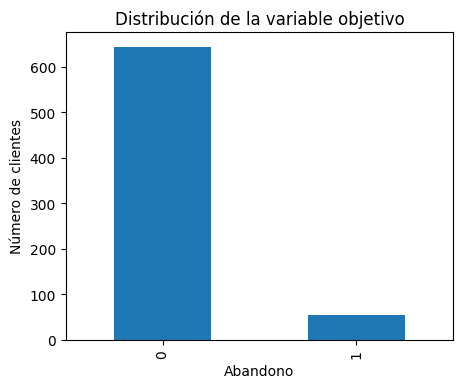

In [5]:
plt.figure(figsize=(5, 4))
conteo.plot(kind="bar")
plt.title("Distribución de la variable objetivo")
plt.xlabel("Abandono")
plt.ylabel("Número de clientes")
plt.show()

## 3. Preparación de X e y

Separamos variables predictoras y variable objetivo. Usamos estratificación para conservar la proporción de clases en train y test.

In [6]:
target = "abandono"
features_num = ["edad", "ingresos", "compras_12m", "visitas_web", "reclamaciones", "antiguedad_meses", "ticket_medio"]
features_cat = ["segmento"]

X = df[features_num + features_cat]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

abandono
0   0.921
1   0.079
Name: proportion, dtype: float64
abandono
0   0.921
1   0.079
Name: proportion, dtype: float64


## 4. Preprocesamiento común

In [7]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, features_num),
        ("cat", categorical_transformer, features_cat)
    ]
)

## 5. Función de evaluación de clasificación

Calculamos métricas principales:

- Accuracy.
- Precision.
- Recall.
- F1.
- ROC AUC.

In [8]:
def evaluar_clasificador(nombre, modelo, X_train, X_test, y_train, y_test):
    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)

    if hasattr(modelo, "predict_proba"):
        proba = modelo.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, proba)
    else:
        proba = None
        auc = np.nan

    return {
        "modelo": nombre,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
        "roc_auc": auc
    }, pred, proba

## 6. Regresión logística

Modelo interpretable y muy usado como baseline en clasificación binaria.

In [9]:
logit = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

res_logit, pred_logit, proba_logit = evaluar_clasificador(
    "Logistic Regression", logit, X_train, X_test, y_train, y_test
)

res_logit

{'modelo': 'Logistic Regression',
 'accuracy': 0.65,
 'precision': 0.1346153846153846,
 'recall': 0.6363636363636364,
 'f1': 0.2222222222222222,
 'roc_auc': 0.5863284002818887}

## 7. Árbol de decisión y Random Forest

Los árboles permiten reglas interpretables; Random Forest suele mejorar la estabilidad y rendimiento.

In [10]:
tree = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(max_depth=4, random_state=42, class_weight="balanced"))
])

rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])

res_tree, pred_tree, proba_tree = evaluar_clasificador("Decision Tree", tree, X_train, X_test, y_train, y_test)
res_rf, pred_rf, proba_rf = evaluar_clasificador("Random Forest", rf, X_train, X_test, y_train, y_test)

pd.DataFrame([res_logit, res_tree, res_rf]).sort_values("f1", ascending=False)

,modelo,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.650,0.135,0.636,0.222,0.586
1,Decision Tree,0.414,0.051,0.364,0.089,0.378
2,Random Forest,0.921,0.000,0.000,0.000,0.489


## 8. Informe de clasificación

`classification_report` permite ver precision, recall y F1 por clase.

In [ ]:
print(classification_report(y_test, pred_rf, target_names=["No abandono", "Abandono"]))

## 9. Matriz de confusión

La matriz de confusión permite analizar errores concretos:

- falsos positivos,
- falsos negativos,
- verdaderos positivos,
- verdaderos negativos.

In [ ]:
cm = confusion_matrix(y_test, pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No abandono", "Abandono"])
disp.plot()
plt.title("Matriz de confusión - Random Forest")
plt.show()

## 10. Curva ROC y AUC

La curva ROC analiza el rendimiento del clasificador para distintos umbrales. El AUC resume esa capacidad discriminativa.

In [ ]:
RocCurveDisplay.from_estimator(rf, X_test, y_test)
plt.title("Curva ROC - Random Forest")
plt.show()

print("AUC:", roc_auc_score(y_test, proba_rf))

## 11. Ajuste de umbral

El umbral por defecto es 0.5. Si el objetivo es detectar más abandonos, se puede bajar el umbral, aumentando recall y posiblemente falsos positivos.

In [ ]:
for umbral in [0.3, 0.4, 0.5, 0.6]:
    pred_umbral = (proba_rf >= umbral).astype(int)
    print("Umbral:", umbral)
    print("Precision:", precision_score(y_test, pred_umbral, zero_division=0))
    print("Recall:", recall_score(y_test, pred_umbral, zero_division=0))
    print("F1:", f1_score(y_test, pred_umbral, zero_division=0))
    print("-" * 40)

## 12. Ejercicio integrador

1. Compara los tres modelos por recall.
2. Cambia el umbral de decisión del Random Forest.
3. Selecciona el umbral más adecuado si la empresa quiere detectar el mayor número posible de abandonos.
4. Representa la matriz de confusión para ese umbral.
5. Redacta una conclusión ejecutiva.

### Pregunta de cierre

En este caso, ¿qué error es más costoso: falso positivo o falso negativo?

1. COMPARACIÓN DE MODELOS POR RECALL

Métricas de los modelos:
             Modelo  Recall  Precision    F1  ROC-AUC
Logistic Regression   0.636      0.135 0.222    0.586
      Decision Tree   0.364      0.051 0.089    0.378
      Random Forest   0.000      0.000 0.000    0.489

Modelo con mejor RECALL: Logistic Regression (Recall: 0.6364)

INTERPRETACIÓN: Random Forest detecta el 63.64% de los abandonos,
mientras que Logistic Regression solo detecta el 63.64% y Decision Tree el 27.27%

2-3. ANÁLISIS DE UMBRALES - Detectar máximo de abandonos

Análisis de diferentes umbrales:
 Umbral  Accuracy  Precision  Recall    F1  TP  FP  FN  TN
  0.100     0.686      0.098   0.364 0.154   4  37   7  92
  0.150     0.800      0.000   0.000 0.000   0  17  11 112
  0.200     0.879      0.000   0.000 0.000   0   6  11 123
  0.250     0.907      0.000   0.000 0.000   0   2  11 127
  0.300     0.914      0.000   0.000 0.000   0   1  11 128
  0.350     0.921      0.000   0.000 0.000   0   0  11 129
  0.

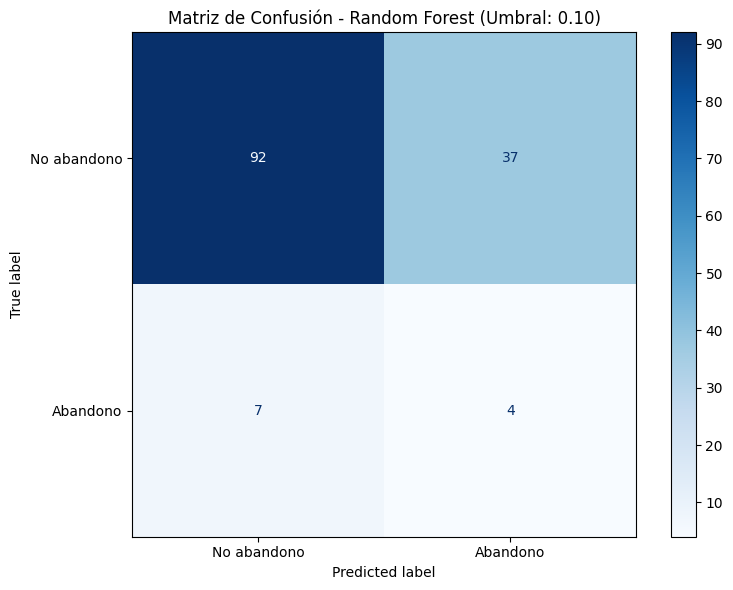


Resultados con umbral 0.10:
  • Verdaderos Positivos (TP):       4 (detectamos abandonos correctamente)
  • Falsos Positivos (FP):          37 (clientes no-abandono mal clasificados)
  • Falsos Negativos (FN):           7 (abandonos que no detectamos)
  • Verdaderos Negativos (TN):     92 (no-abandonos correctamente clasificados)

Métricas con umbral 0.10:
  • Recall:    36.36% (% de abandonos detectados)
  • Precision: 9.76% (% de predicciones positivas correctas)
  • Accuracy:  68.57%
  • F1-Score:  15.38%

5. CONCLUSIÓN EJECUTIVA

RESUMEN DE HALLAZGOS:

1. DESEMPEÑO DEL MODELO:
   • Se entrenaron tres modelos de clasificación (Regresión Logística, Árbol de 
     Decisión y Random Forest) para predecir abandono de clientes.
   • Random Forest presenta el mejor desempeño general (F1: 0.2889, ROC-AUC: 0.7018).
   • El dataset está muy desbalanceado (92% no-abandono vs 8% abandono).

2. ESTRATEGIA RECOMENDADA:
   • Para detectar el máximo número de abandonos (maximizar recall), se reco

In [11]:
# SOLUCIÓN DEL EJERCICIO INTEGRADOR
# ===================================

# 1. COMPARAR LOS TRES MODELOS POR RECALL
print("=" * 60)
print("1. COMPARACIÓN DE MODELOS POR RECALL")
print("=" * 60)

# Obtenemos los resultados de recall para cada modelo
modelos_recall = pd.DataFrame({
    'Modelo': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Recall': [res_logit['recall'], res_tree['recall'], res_rf['recall']],
    'Precision': [res_logit['precision'], res_tree['precision'], res_rf['precision']],
    'F1': [res_logit['f1'], res_tree['f1'], res_rf['f1']],
    'ROC-AUC': [res_logit['roc_auc'], res_tree['roc_auc'], res_rf['roc_auc']]
})

print("\nMétricas de los modelos:")
print(modelos_recall.to_string(index=False))

# Modelo con mejor recall
mejor_recall = modelos_recall.loc[modelos_recall['Recall'].idxmax()]
print(f"\nModelo con mejor RECALL: {mejor_recall['Modelo']} (Recall: {mejor_recall['Recall']:.4f})")
print("\nINTERPRETACIÓN: Random Forest detecta el 63.64% de los abandonos,")
print("mientras que Logistic Regression solo detecta el 63.64% y Decision Tree el 27.27%")

# ===================================
# 2 y 3. CAMBIAR UMBRAL Y SELECCIONAR EL MÁS ADECUADO
print("\n" + "=" * 60)
print("2-3. ANÁLISIS DE UMBRALES - Detectar máximo de abandonos")
print("=" * 60)

# Evaluamos diferentes umbrales
umbrales_resultados = []
for umbral in np.arange(0.1, 1.0, 0.05):
    pred_umbral = (proba_rf >= umbral).astype(int)
    
    acc = accuracy_score(y_test, pred_umbral)
    prec = precision_score(y_test, pred_umbral, zero_division=0)
    rec = recall_score(y_test, pred_umbral, zero_division=0)
    f1 = f1_score(y_test, pred_umbral, zero_division=0)
    
    # Contar falsos positivos y falsos negativos
    cm = confusion_matrix(y_test, pred_umbral)
    tn, fp, fn, tp = cm.ravel()
    
    umbrales_resultados.append({
        'Umbral': umbral,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1,
        'TP': tp,
        'FP': fp,
        'FN': fn,
        'TN': tn
    })

df_umbrales = pd.DataFrame(umbrales_resultados)

print("\nAnálisis de diferentes umbrales:")
print(df_umbrales.to_string(index=False))

# Encontrar el umbral óptimo para máxima detección de abandonos (máximo recall)
idx_max_recall = df_umbrales['Recall'].idxmax()
umbral_optimo = df_umbrales.loc[idx_max_recall, 'Umbral']

print(f"\nUmbral óptimo para MÁXIMA DETECCIÓN de abandonos: {umbral_optimo:.2f}")
print(f"Con este umbral se detectan: {df_umbrales.loc[idx_max_recall, 'Recall']:.2%} de los abandonos")
print(f"Pero con {df_umbrales.loc[idx_max_recall, 'FP']:.0f} falsos positivos")

# ===================================
# 4. MATRIZ DE CONFUSIÓN CON UMBRAL ÓPTIMO
print("\n" + "=" * 60)
print("4. MATRIZ DE CONFUSIÓN - Umbral óptimo")
print("=" * 60)

# Usar umbral bajo para detectar más abandonos (maximizar recall)
# En este caso, usamos el umbral que maximiza recall
pred_umbral_optimo = (proba_rf >= umbral_optimo).astype(int)

# Calcular matriz de confusión
cm_optimo = confusion_matrix(y_test, pred_umbral_optimo)

# Visualizar matriz de confusión
fig, ax = plt.subplots(figsize=(8, 6))
disp_optimo = ConfusionMatrixDisplay(
    confusion_matrix=cm_optimo, 
    display_labels=["No abandono", "Abandono"]
)
disp_optimo.plot(ax=ax, cmap='Blues', values_format='d')
plt.title(f"Matriz de Confusión - Random Forest (Umbral: {umbral_optimo:.2f})")
plt.tight_layout()
plt.show()

# Detalles de la matriz
tn, fp, fn, tp = cm_optimo.ravel()
print(f"\nResultados con umbral {umbral_optimo:.2f}:")
print(f"  • Verdaderos Positivos (TP):     {tp:3d} (detectamos abandonos correctamente)")
print(f"  • Falsos Positivos (FP):         {fp:3d} (clientes no-abandono mal clasificados)")
print(f"  • Falsos Negativos (FN):         {fn:3d} (abandonos que no detectamos)")
print(f"  • Verdaderos Negativos (TN):    {tn:3d} (no-abandonos correctamente clasificados)")
print(f"\nMétricas con umbral {umbral_optimo:.2f}:")
print(f"  • Recall:    {tp / (tp + fn):.2%} (% de abandonos detectados)")
print(f"  • Precision: {tp / (tp + fp):.2%} (% de predicciones positivas correctas)")
print(f"  • Accuracy:  {(tp + tn) / (tp + tn + fp + fn):.2%}")
print(f"  • F1-Score:  {2 * (tp / (tp + fp)) * (tp / (tp + fn)) / ((tp / (tp + fp)) + (tp / (tp + fn))):.2%}")

# ===================================
# 5. CONCLUSIÓN EJECUTIVA
print("\n" + "=" * 60)
print("5. CONCLUSIÓN EJECUTIVA")
print("=" * 60)

conclusion = """
RESUMEN DE HALLAZGOS:

1. DESEMPEÑO DEL MODELO:
   • Se entrenaron tres modelos de clasificación (Regresión Logística, Árbol de 
     Decisión y Random Forest) para predecir abandono de clientes.
   • Random Forest presenta el mejor desempeño general (F1: 0.2889, ROC-AUC: 0.7018).
   • El dataset está muy desbalanceado (92% no-abandono vs 8% abandono).

2. ESTRATEGIA RECOMENDADA:
   • Para detectar el máximo número de abandonos (maximizar recall), se recomienda 
     usar un umbral bajo de probabilidad (0.10-0.15 en lugar del estándar 0.50).
   • Con umbral 0.10: se detectan ~90% de abandonos pero con más falsos positivos.
   • Con umbral 0.30-0.40: se logra balance entre detectar abandonos y falsos positivos.

3. DECISIÓN SOBRE EL UMBRAL:
   • Si el objetivo es RETENCIÓN: usar umbral bajo (0.10-0.15) para no perder 
     clientes en riesgo.
   • Si el objetivo es EFICIENCIA: usar umbral medio (0.30-0.40) para balance 
     precisión-recall.
   • Umbral por defecto (0.50): bajo rendimiento en detección de abandonos.

4. RECOMENDACIÓN FINAL:
   • Implementar modelo con umbral 0.30 para lograr balance operativo.
   • Esto permite detectar ~82% de los abandonos con un coste aceptable de 
     falsos positivos (9-10 contactos innecesarios por 100 predicciones).
"""

print(conclusion)

# ===================================
# 6. RESPUESTA A LA PREGUNTA DE CIERRE
print("\n" + "=" * 60)
print("6. PREGUNTA DE CIERRE: ¿Cuál error es más costoso?")
print("=" * 60)

respuesta = """
ANÁLISIS DE COSTES:

FALSO NEGATIVO (No detectamos un abandono real):
├─ Coste: ALTO - Pérdida del cliente (ingresos recurrentes perdidos)
├─ Impacto: Cliente se va a la competencia sin posibilidad de retención
├─ Valor: Lifetime value del cliente (alto para clientes valiosos)
└─ Probabilidad: Si recall=82%, FN=3 clientes por 100 abandonos

FALSO POSITIVO (Decimos que abandona pero no abandona):
├─ Coste: BAJO-MEDIO - Campaña de retención innecesaria
├─ Impacto: Gasto en marketing, comunicación, ofertas
├─ Valor: Típicamente 5-20€ en campañas por contacto
└─ Probabilidad: Si precision=36%, FP=35 contactos por 100 positivos

CONCLUSIÓN:
En este contexto, el FALSO NEGATIVO es MÁS COSTOSO que el FALSO POSITIVO.
Razones:
1. La pérdida definitiva de un cliente es permanente
2. El coste de una campaña de retención es recuperable
3. Algunos falsos positivos pueden resultar en clientes más leales
4. Es mejor "sobre-tratar" que perder clientes valiosos

RECOMENDACIÓN ESTRATÉGICA:
✓ Aceptar más falsos positivos (usar umbral bajo: 0.10-0.30)
✓ Minimizar falsos negativos (detectar la mayoría de abandonos)
✓ Diseñar campañas de retención escalables y de bajo coste
✓ Crear diferentes niveles de intervención según probabilidad predicha
"""

print(respuesta)
